# Manual adjustment of dmdpsi testing

## Logistic and Fermi functions

-0.9999797360577568


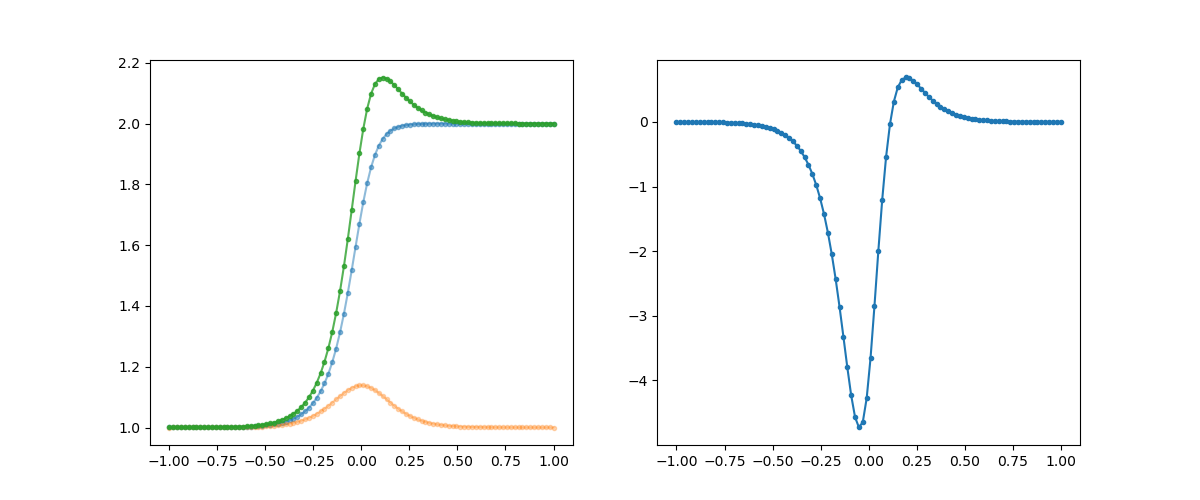

In [122]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

x = np.linspace(-1,1,100)
A = 1
K = 2
C = 1
Q = 1
B = 20
nu = 2

alpha = 1
ll = 10
mu = 0


y_logistic = A + (K-A)/(C + Q*np.exp(-B*x))**(1/nu)
y_fermi = 1+alpha*ll*np.exp(-ll*(x - mu))/(1 + np.exp(-ll*(x-mu)))**(1+alpha)/18

deriv = -np.gradient(y_logistic*y_fermi,x)

area = simpson(deriv,x=x)
print(area)

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(x,y_logistic,'.-',alpha = 0.5)
ax.plot(x,y_fermi,'.-',alpha=0.3)
ax.plot(x,y_logistic*y_fermi,'.-',alpha = 0.8)
ax2.plot(x,deriv,'.-')
plt.show()


Notice that the area under the deriv plot is equal to the difference between the green curve at x=-1 and x=1 (makes sense, according to the fundamental theorem of calculus). So setting this difference sets the area under the curve. Use this to our advantage!

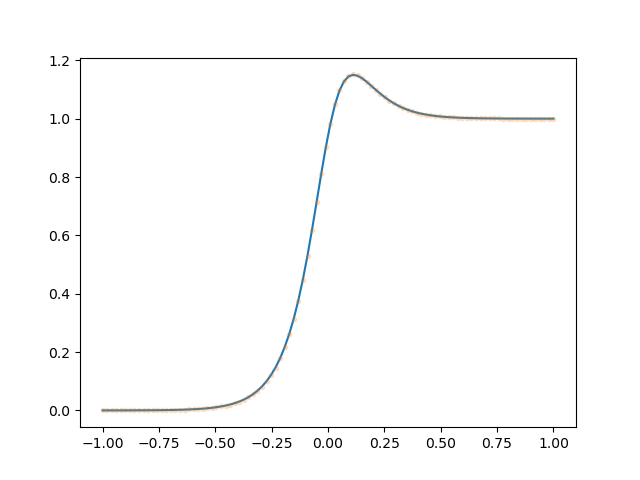

In [123]:
cumulative_area = [np.array(simpson(deriv[:i+1],x[:i+1])) for i in range(len(deriv))]
fig,ax = plt.subplots()
ax.plot(x,-np.array(cumulative_area))
ax.plot(x,y_logistic*y_fermi - 1,'.',alpha=0.2)
plt.show()

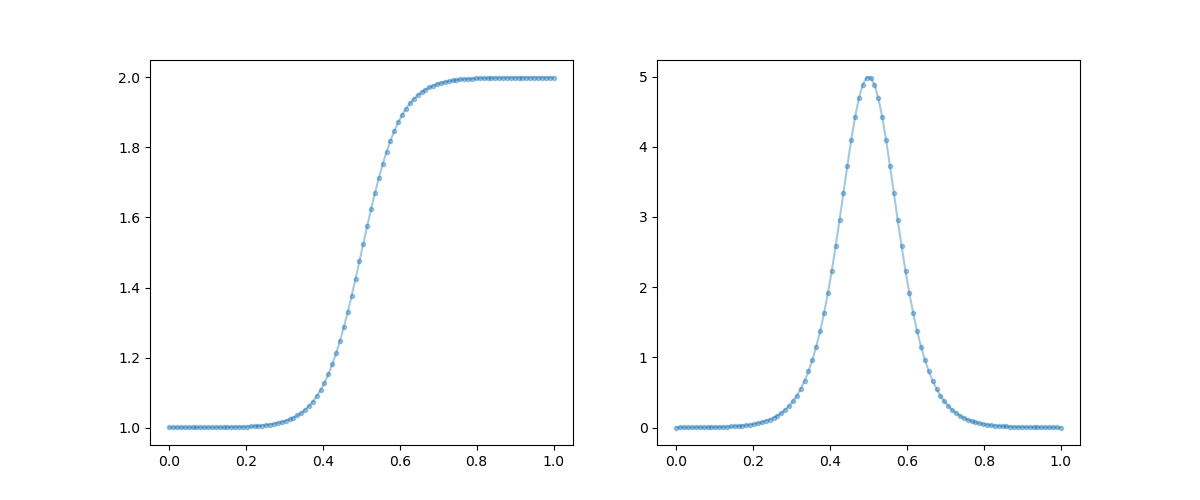

In [124]:
# logistic function derivative
A = 1
K = 2.
B = 20
C = 1
Q = 1
nu = 1
t0 = 0.5
t = np.linspace(0,1,100)
y = A + (K-A)/(C + Q*np.exp(-B*(t- t0)))**(1./nu)
dydt = B*Q*(K-A)*np.exp(-B*(t-t0))/nu/(C + Q*np.exp(-B*(t-t0)))**((nu+1)/nu)

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(t,y,'.-',alpha=0.4)
ax2.plot(t,dydt,'.-',alpha=0.4)
plt.show()

### logistic function derivative

### PRHL function

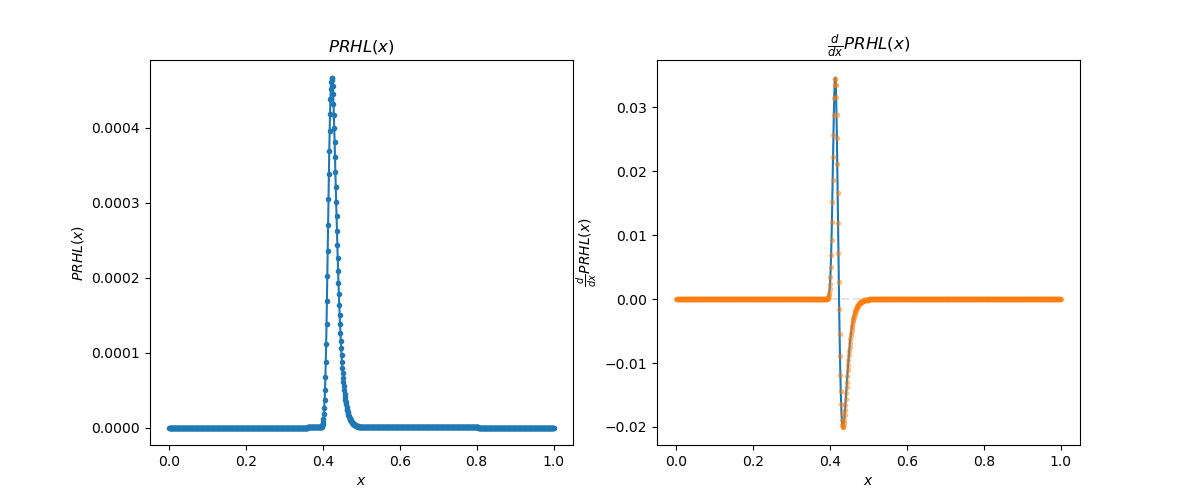

In [125]:
# Try proportional reversed hazard logistic (PRHL) function  (https://home.iitk.ac.in/~kundu/paper152.pdf)
def prhl(x, alpha, mu, ll):
    return alpha*np.exp(-ll*(x-mu))/(1 + np.exp(-ll*(x-mu)))**(alpha+1)

# derivative:
def d_prhl(x,alpha,mu,ll):
    return -alpha*ll*(np.exp(ll*(x - mu)) - alpha)/(1 + np.exp(-ll*(x-mu)))**alpha/(1 + np.exp(ll*(x - mu)))**2
x = np.linspace(0,1,1000)
alpha = 10
mu = 0.4
ll = 100
prhl_test = prhl(x,alpha,mu,ll)/750
test_d_prhl = d_prhl(x,alpha,mu,ll)/750

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(x,prhl_test,'.-')
ax2.plot(x,test_d_prhl,'-')
ax2.plot(x,np.zeros_like(x),'--k',alpha = 0.1)
ax2.plot(x,np.gradient(prhl_test,x),'.',alpha=0.4)
ax.set(title=r'$PRHL(x)$',xlabel='$x$',ylabel=r'$PRHL(x)$')
ax2.set(title=r'$\frac{d}{dx}PRHL(x)$',xlabel='$x$',ylabel=r'$\frac{d}{dx}PRHL(x)$')
plt.show()

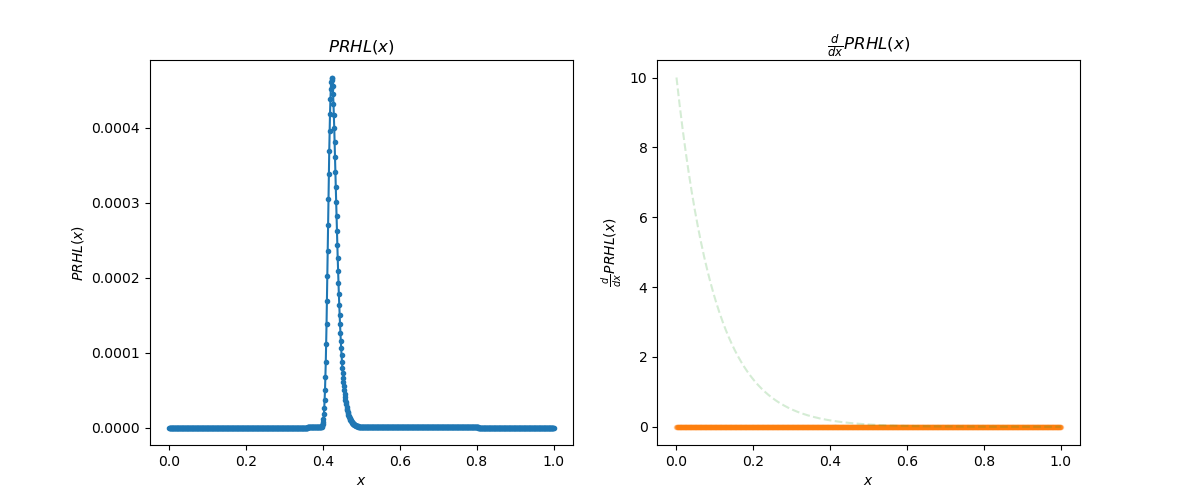

In [126]:
A0 = 10
ll2 = 10

fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.plot(x,prhl_test,'.-')
ax2.plot(x,test_d_prhl,'-',alpha=0.2)
ax2.plot(x,test_d_prhl*A0*np.exp(-ll2*x),'.',alpha=0.3)
ax2.plot(x,A0*np.exp(-ll2*x),'--',alpha=0.2)
# ax2.plot(x,np.zeros_like(x),'--k',alpha = 0.1)
# ax2.plot(x,np.gradient(prhl_test,x),'.',alpha=0.4)
ax.set(title=r'$PRHL(x)$',xlabel='$x$',ylabel=r'$PRHL(x)$')
ax2.set(title=r'$\frac{d}{dx}PRHL(x)$',xlabel='$x$',ylabel=r'$\frac{d}{dx}PRHL(x)$')
plt.show()

## Matrix solution for spline coefficients

0.004570719794997455 0.003139533229968211
(9, 9)
[ 6.06398626e-02 -6.06408753e-01 -1.58550289e+02  5.78405507e+03
  3.19839630e-02  3.13639370e-02  0.00000000e+00 -1.15529206e+02
  3.72293035e+03]
0.03136393696738244 0.031983963008319086


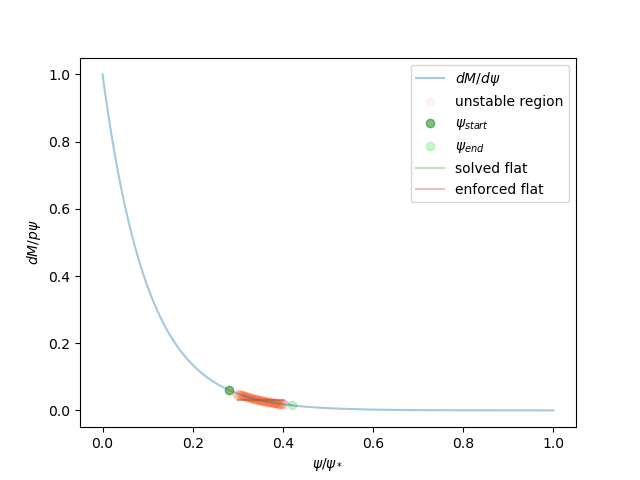

In [127]:
# solve matrix solution for coefficients of matrix

x = np.linspace(0,1,1000)
y = np.exp(-10*x)

start_index = 300
end_index = 400

mass = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

ghost_points_0 = 20
ghost_points_3 = 20

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]


L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])
print(total_mass,mass)

A = [[1, 0, 0, 0, 0, 0, 0, 0, 0],[1, L1, L1**2,L1**3, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 1, 0, 0, 0],[0, 0, 0, 0, 0, 1,L3, L3**2, L3**3],[0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 1,2*L1,3*L1**2, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 1, 0, 0],[0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2], [L1, L1**2/2, L1**3/3, L1**4/4, L2, L3,L3**2/2, L3**3/3,L3**4/4]]
b = [dmdpsi_0, flats[0], flats[0], dmdpsi_3, k0, 0, 0, k3, total_mass]

# A = [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],[1, L1, L1**2,L1**3, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],[0, 0, 0, 0, 0, 0, 1,L3, L3**2, L3**3],[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
#      [0, 1,2*L1,3*L1**2, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],[0, 0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2], [L1, L1**2/2, L1**3/3, L1**4/4, L2, L2**2/2, L3,L3**2/2, L3**3/3,L3**4/4],
#     [0, 0, 0, 0, 1, L2, 0, 0, 0, 0]]
# b = [dmdpsi_0, flats[0], flats[0], dmdpsi_3, k0, 0, 0, k3, total_mass, flats[0]]
print(np.shape(A))
xx = np.linalg.solve(A,b)
print(xx)

a1 = xx[0]
b1 = xx[1]
c1 = xx[2]
d1 = xx[3]
a2 = xx[4]
a3 = xx[5]
b3 = xx[6]
c3 = xx[7]
d3 = xx[8]

# a1 = xx[0]
# b1 = xx[1]
# c1 = xx[2]
# d1 = xx[3]
# a2 = xx[4]
# b2 = xx[5]
# a3 = xx[6]
# b3 = xx[7]
# c3 = xx[8]
# d3 = xx[9]

x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1] - x_10) + c1*(x[start_index-ghost_points_0:start_index+1] - x_10)**2 + d1*(x[start_index-ghost_points_0:start_index+1] - x_10)**3
y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3

print(flats[0], a2 )

%matplotlib widget
fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

In [128]:
# check area under curve
area_1 = simpson(y1,x[start_index-ghost_points_0:start_index+1])
area_2 = simpson(flats,x[start_index:end_index+1])
area_3 = simpson(y3,x[end_index:end_index + ghost_points_3+1])
updated_total_area = area_1+area_2+area_3

print(f"original area: {total_mass}")
print(f"updated area : {updated_total_area}")
print(f"pct: {(total_mass - updated_total_area)/total_mass * 100:0.5f}%")


original area: 0.004570719794997455
updated area : 0.004508655126235028
pct: 1.35788%


### Quadratic middle section

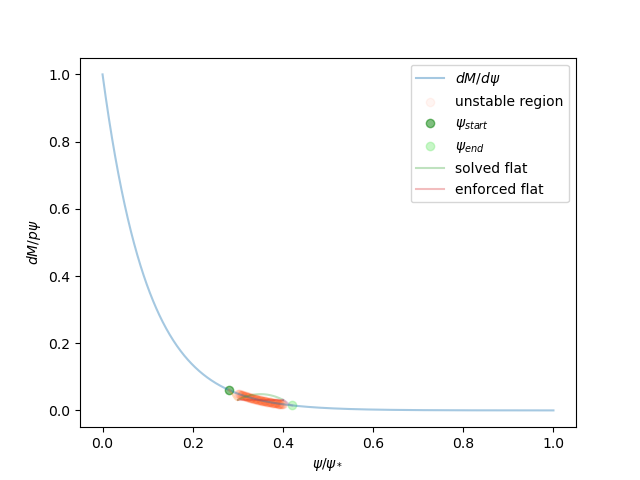

In [129]:
# try a quadratic middle section:
B = [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[1, L1, L1**2, L1**3, 0, 0, 0, 0, 0, 0, 0, 0],[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 1, 2*L1, 3*L1**2, 0, -1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, L2, L2**2,L2**3, 0, 0, 0, 0],[0, 0, 0, 0, 0, 1, 2*L2, 3*L2**2, 0, -1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 0, 1, L3, L3**2, L3**3], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2],[L1, L1**2/2, L1**3, L1**4/4, L2, L2**2/2, L2**3/3, L2**4/4, L3, L3**2/2, L3**3/3, L3**4/4],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]]
b2 = [dmdpsi_0, flats[0], k0, 0, flats[0],0, dmdpsi_3, k3, total_mass, flats[0],flats[0], 0]

xxx = np.linalg.solve(B,b2)
a1 = xxx[0]
b1 = xxx[1]
c1 = xxx[2]
d1 = xxx[3]
a2 = xxx[4]
b2 = xxx[5]
c2 = xxx[6]
d2 = xxx[7]
a3 = xxx[8]
b3 = xxx[9]
c3 = xxx[10]
d3 = xxx[11]

def cubic(a,b,c,d,x,x0):
    return a + b*(x - x0) + c*(x-x0)**2 + d*(x-x0)**3

y1 = cubic(a1,b1,c1,d1,x[start_index-ghost_points_0:start_index+1],x_10)
y2 = cubic(a2,b2,c2,d2,x[start_index:end_index+1],x_20)
y3 = cubic(a3,b3,c3,d3,x[end_index:end_index + ghost_points_3+1],x_30)

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()


No - this way isn't great, because the use of cubic polynomials minimises the bending energy $\int_L |\mathbf{p}(x)|^2 dx$, which means the curvature will be minimised near the endpoints of the flat section, which is a condition we are not seeking to impose (we don't care about bending energy). So instead, enforce the flat section. It turns out that moving the ultimate endpoints nearer the unstable region reduces the error, so just reduce them to an acceptable amount (i.e. mass error less than 1%). This is performed in the plot above.



## Region clumping algorithm

Brainstorm the super-region method to code tomorrow.
0. Start with region array of ones and zeros indicating where instabilities are located, as well as array identifying the indices of the region midpoints and endpoints. Create super-region array of zeros.
1. Beginning with the first region, calculate region width $L_0$ and midpoint $x_0$
2. Identify any subsequent region midpoint within $x_0 \pm L_0$ of the first region. If so, update super-region array to be one between $x_{min,0} - \Delta L$ and $x_{max,i} + \Delta L$, where $i$ is the index of the maximum captured region, and $\Delta L$ is some padding width.
3. Jump to next adjacent region outside of the newly created region, at $x_{i+1}$.
4. Return to step 1.

Test this below:

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


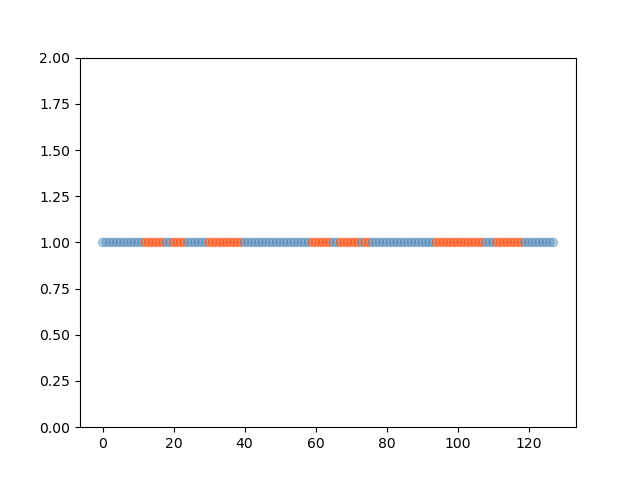

In [130]:
# create test instability array
stability_array = np.zeros(128)
test_midpoints = np.array([15, 22, 35, 62, 70, 75 , 101, 115])
test_half_widths = np.array([3, 2, 5, 3, 3, 1, 7, 4])

for i in range(len(test_midpoints)):
    stability_array[test_midpoints[i] - test_half_widths[i] : test_midpoints[i] + test_half_widths[i]] = 1

print(stability_array)

fig,ax = plt.subplots()
ax.scatter(np.arange(0,len(stability_array),1),np.ones_like(stability_array), c=np.where(stability_array == 1, "orangered", "steelblue"), alpha = 0.4)
ax.set(ylim=[0,2])
plt.show()

In [131]:
import sys
width_factor = 10
# assign super-region array
super_stability_array = np.zeros_like(stability_array)

# calculate array of the lower and upper boundaries of all regions
region_min_indices = test_midpoints - test_half_widths
region_max_indices = test_midpoints + test_half_widths
print(region_min_indices,region_max_indices)

i = 0
iterations = 0

while i < len(test_midpoints)-1:
    super_region_lower_index = region_min_indices[i]
    super_region_upper_index = region_max_indices[i]
    
    # calculate max extent of i-th superregion
    max_index = test_midpoints[i] + width_factor*test_half_widths[i]

    if(max_index > len(stability_array)):
        max_index = len(stability_array)

    # calculate highest captured superregion midpoint: index array locates the regions which have a lower boundary closer than x_midpoint + 2*half_widths from region in question
    captured_regions_array = np.where(region_min_indices < max_index, 1,0)
    # min_captured_regions_array = np.where(region_max_indices > min_index,1,0)
    
    if(max_index < region_min_indices[-1]):
        max_captured_midpoint_index = (np.where(captured_regions_array==0)[0]-1)[0]
        super_region_upper_index = region_max_indices[max_captured_midpoint_index]
    else:
        max_captured_midpoint_index = len(test_midpoints)-1
        super_region_upper_index = region_max_indices[-1]

    
    # assign all points inside superregion equal to 1
    super_stability_array[super_region_lower_index:super_region_upper_index] = 1

    i = max_captured_midpoint_index + 1
    iterations += 1
    
    if(iterations > 15):
        break
    
print(stability_array)
print(super_stability_array)
    

[ 12  20  30  59  67  74  94 111] [ 18  24  40  65  73  76 108 119]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


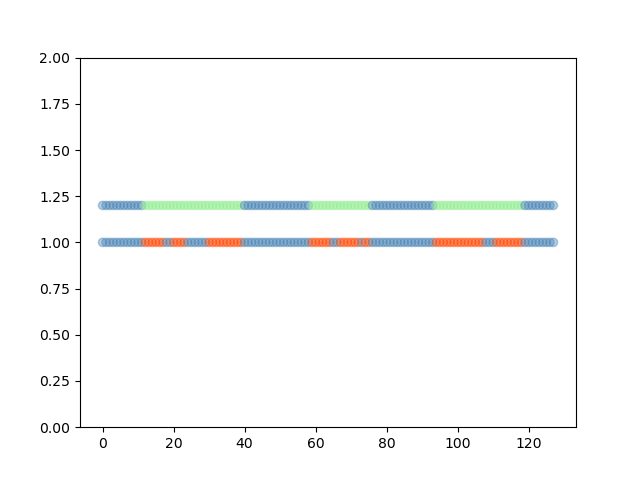

In [132]:
fig,ax = plt.subplots()
ax.scatter(np.arange(0,len(stability_array),1),np.ones_like(stability_array), c=np.where(stability_array == 1, "orangered", "steelblue"), alpha = 0.4)
ax.scatter(np.arange(0,len(stability_array),1),1.2*np.ones_like(stability_array), c=np.where(super_stability_array == 1, "lightgreen", "steelblue"), alpha = 0.4)
ax.set(ylim=[0,2])
plt.show()

## Return to spline method
### Unstable region at boundary, first attempt
Need to consider unstable regions located at boundaries where splines cannot be made. Strategy will be as follows:
1. If the region is N_min > N > N_preset points away from the boundary, where N_preset is the preset number of points that the spline covers (e.g. 10), and N_min is some minimum number of spline points we are comfortable using to construct a spline, then set N_preset = N.
2. If the region is N > N_preset, use N = N_preset (all is well)
3. If N < N_min, don't construct a spline here. Instead, we only need to solve the spline on the other side.

Formulate the problem when only solving for one spline: try setting a1=b1=c1=d1=0 in matrix to ignore them?



In [133]:
# solve matrix solution for coefficients of matrix

x = np.linspace(0,1,1000)
y = np.exp(-10*x)

unstable_start_index = 1
unstable_end_index = 8
ghost_points_0 = 10
ghost_points_3 = 10

if(unstable_start_index < ghost_points_0):
    start_index = ghost_points_0
else:
    start_index = unstable_start_index

if(start_index > end_index):
    start_index = unstable_start_index
    ghost_points_0 = unstable_start_index

print(start_index,end_index)
print(ghost_points_0)

# start_index = 21
end_index = unstable_end_index


mass = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]


L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])

A = [[1, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, L1, L1**2,L1**3, 0, 0, 0, 0, 0],
     [0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 1,2*L1,3*L1**2, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, L3, L3**2, L3**3],
     [0, 0, 0, 0, 0, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2], 
     [L1, L1**2/2, L1**3/3, L1**4/4, L2, L3,L3**2/2, L3**3/3,L3**4/4]]

b = [dmdpsi_0, flats[0], k0, 0, flats[0], dmdpsi_3, 0, k3, total_mass]

xx = np.linalg.solve(A,b)
print(xx)

a1 = xx[0]
b1 = xx[1]
c1 = xx[2]
d1 = xx[3]
a2 = xx[4]
a3 = xx[5]
b3 = xx[6]
c3 = xx[7]
d3 = xx[8]

# a1 = xx[0]
# b1 = xx[1]
# c1 = xx[2]
# d1 = xx[3]
# a2 = xx[4]
# b2 = xx[5]
# a3 = xx[6]
# b3 = xx[7]
# c3 = xx[8]
# d3 = xx[9]

x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1] - x_10) + c1*(x[start_index-ghost_points_0:start_index+1] - x_10)**2 + d1*(x[start_index-ghost_points_0:start_index+1] - x_10)**3
y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3

# check area under curve
area_1 = simpson(y1,x[start_index-ghost_points_0:start_index+1])
area_2 = simpson(flats,x[start_index:end_index+1])
area_3 = simpson(y3,x[end_index:end_index + ghost_points_3+1])
updated_total_area = area_1+area_2+area_3

print(f"original area: {total_mass}")
print(f"updated area : {updated_total_area}")
print(f"pct: {(total_mass - updated_total_area)/total_mass * 100:0.5f}%")

%matplotlib widget
fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[unstable_start_index:unstable_end_index+1],y[unstable_start_index:unstable_end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()


10 400
10


ValueError: cannot select an axis to squeeze out which has size not equal to one

To do: 
- watch the progression at each step
- redistribute mass near the pole, since it continues to sit in the first spline
- check whether the enforcement of the flat section to the "flats" amount rather than y2 causes a large discrepancy in the total integrated mass
- figure out why the plot goes negative

### Quartics, instead of cubics
We have 5 equations per spline - 2 equations for the continuity at either end of the spline, 2 for the continuity of the derivative at either end, and one for the integral constraint. However, with cubics, we have 4 unknowns (a,b,c,d), so we have one more constraint than unknowns. How about trying a quartic, which will have the extra coefficient (e_i), such that there are 5 unknowns, and 5 equations, per spline. Try that!

0.007187418011503658 0.007187418011503658 0.003139533229968211
(11, 11) (11,)
[ 8.18798375e-02 -8.18812049e-01  1.06507314e+02 -4.88708613e+03
  5.36068205e+04  3.13639370e-02  3.13639370e-02  0.00000000e+00
 -7.82336421e+01  2.23858037e+03 -1.72256705e+04]
0.03136393696738244 0.03136393696738244


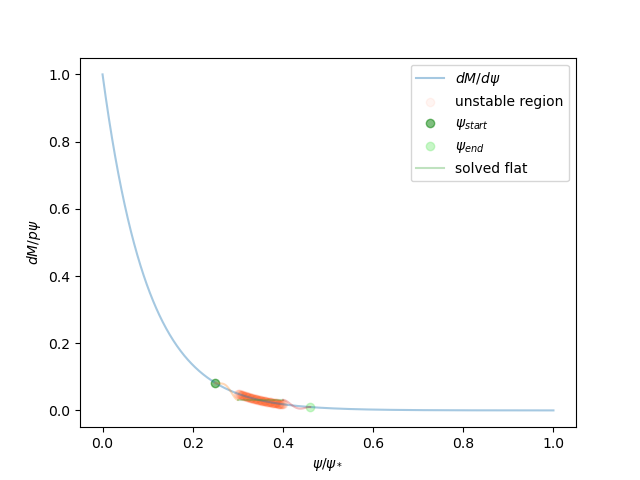

In [136]:
# solve matrix solution for coefficients of matrix

x = np.linspace(0,1,1000)
y = np.exp(-10*x)

start_index = 300
end_index = 400

mass = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

ghost_points_0 = 50
ghost_points_3 = 60

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]


L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])
mass_1 = simpson(y[start_index - ghost_points_0:start_index+1], x[start_index - ghost_points_0:start_index+1])
mass_3 = simpson(y[end_index:end_index+ghost_points_3 + 1], x[end_index:end_index+ghost_points_3 + 1])
print(total_mass,mass+mass_1+mass_3, mass)

A = [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, L1, L1**2,L1**3, L1**4, 0, 0, 0, 0, 0, 0],
     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
     [0, 1, 2*L1,3*L1**2, 4*L1**3, 0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 1,L3, L3**2, L3**3, L3**4],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2, 4*L3**3], 
     [L1, L1**2/2, L1**3/3, L1**4/4, L1**5/5, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, L3,L3**2/2, L3**3/3,L3**4/4, L3**5/5]]

b = [dmdpsi_0, flats[0], k0, 0, flats[0], flats[0], dmdpsi_3, 0, k3, mass_1, mass_3]

print(np.shape(A),np.shape(b))

# A = [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],[1, L1, L1**2,L1**3, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],[0, 0, 0, 0, 0, 0, 1,L3, L3**2, L3**3],[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
#      [0, 1,2*L1,3*L1**2, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],[0, 0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2], [L1, L1**2/2, L1**3/3, L1**4/4, L2, L2**2/2, L3,L3**2/2, L3**3/3,L3**4/4],
#     [0, 0, 0, 0, 1, L2, 0, 0, 0, 0]]
# b = [dmdpsi_0, flats[0], flats[0], dmdpsi_3, k0, 0, 0, k3, total_mass, flats[0]]

xx = np.linalg.solve(A,b)
print(xx)

a1 = xx[0]
b1 = xx[1]
c1 = xx[2]
d1 = xx[3]
e1 = xx[4]
a2 = xx[5]
a3 = xx[6]
b3 = xx[7]
c3 = xx[8]
d3 = xx[9]
e3 = xx[10]

# a1 = xx[0]
# b1 = xx[1]
# c1 = xx[2]
# d1 = xx[3]
# a2 = xx[4]
# b2 = xx[5]
# a3 = xx[6]
# b3 = xx[7]
# c3 = xx[8]
# d3 = xx[9]

x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1] - x_10) + c1*(x[start_index-ghost_points_0:start_index+1] - x_10)**2 + d1*(x[start_index-ghost_points_0:start_index+1] - x_10)**3 + e1*(x[start_index-ghost_points_0:start_index+1] - x_10)**4
y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3 + e3*(x[end_index:end_index + ghost_points_3+1] - x_30)**4

print(flats[0], a2)

%matplotlib widget
fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
# ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

In [ ]:
a = "hello world"
print(type(a))
if type(a) == str:
    print("test")

### Remove unnecessary boundary conditions - end of spline gradient smoothness
Based off discussions with Andrew, we relax the condition of the smoothness of the derivative at the right spline endpoint, allowing this equation in the matrix to be replaced by the condition that a2 is equal to delta M / delta psi. The matrix will therefore look like:

0.03178735958289206 0.031787359582892055 0.01409155437596074
total mass = 0.03178735958289206, checkmass = 0.03178735958289206, pct = 0.0%


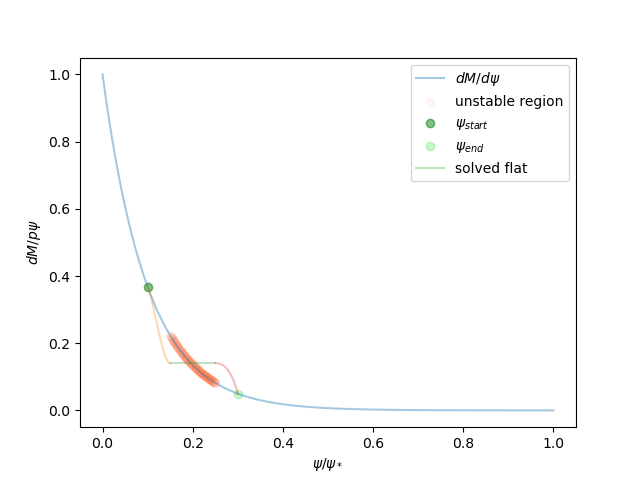

In [137]:
start_index = 150
end_index = 250

mass = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

ghost_points_0 = 50
ghost_points_3 = 50

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]


L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])
mass_1 = simpson(y[start_index - ghost_points_0:start_index+1], x[start_index - ghost_points_0:start_index+1])
mass_3 = simpson(y[end_index:end_index+ghost_points_3 + 1], x[end_index:end_index+ghost_points_3 + 1])

print(total_mass,mass+mass_1+mass_3, mass)

A = [[1, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, L1, L1**2,L1**3, 0, 0, 0, 0, 0],
     [0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 1, 2*L1,3*L1**2, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1,L3, L3**2, L3**3],
     [0, 0, 0, 0, 0, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 1, 0, 0, 0], 
     [L1, L1**2/2, L1**3/3, L1**4/4, L2, L3,L3**2/2, L3**3/3,L3**4/4]]

b = [dmdpsi_0, flats[0], k0, 0, flats[0], dmdpsi_3, 0, flats[0], total_mass]

xx = np.linalg.solve(A,b)
a1 = xx[0]
b1 = xx[1]
c1 = xx[2]
d1 = xx[3]
a2 = xx[4]
a3 = xx[5]
b3 = xx[6]
c3 = xx[7]
d3 = xx[8]

x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1] - x_10) + c1*(x[start_index-ghost_points_0:start_index+1] - x_10)**2 + d1*(x[start_index-ghost_points_0:start_index+1] - x_10)**3
y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3

# find checkmass
checkmass = simpson(y1,x[start_index-ghost_points_0:start_index+1]) + simpson(y2,x[start_index:end_index+1]) + simpson(y3,x[end_index:end_index + ghost_points_3+1])

print(f"total mass = {total_mass}, checkmass = {checkmass}, pct = {(total_mass - checkmass)/total_mass * 100}%")

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
# ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

Next step - need to figure out a way to ensure mass from the first fluxtube gets transported if unstable. How about this? We pick N ghost points for the left spline. Then, for the first N flux surfaces, any mass transport in these N flux tubes is calculated using the old method whereby the mass required to be moved is calculated by equalising the mass in adjacent flux tubes. After the N surfaces, the spline method is used. Nah, just remove the first spline if the unstable region starts at psi=0. Most consistent way.

(5, 5)
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 5.00500501e-02 2.50500751e-03
  1.25375751e-04]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.00100100e-01 5.00500501e-02 1.25250376e-03 4.17919171e-05
  1.56876566e-06]]
[0.14077463 0.04963778 0.         0.14077463 0.03178736]


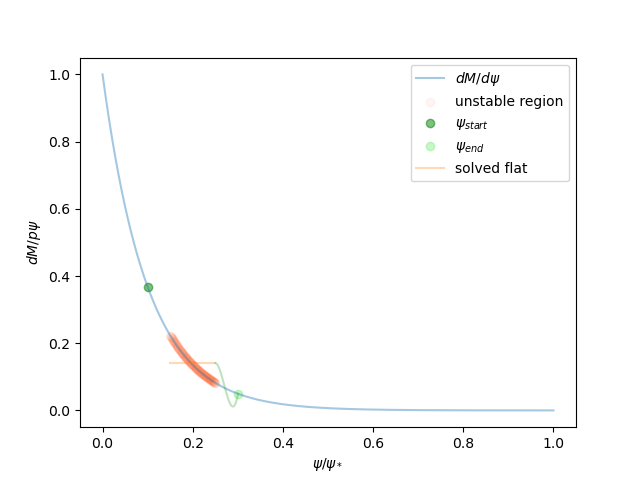

In [138]:
A2 = np.array(A)[4:,4:]
print(np.shape(A2))
mass2and3 = total_mass - mass_1
b2 = np.copy(b)[4:]
print(A2)
print(b2)


mass2 = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
mass3 = simpson(y[end_index:end_index+ghost_points_3+1],x[end_index:end_index+ghost_points_3+1])
b2[-1] = mass2 + mass_3
yy = np.linalg.solve(A2,b2)
a2 = yy[0]
a3 = yy[1]
b3 = yy[2]
c3 = yy[3]
d3 = yy[4]

y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
# ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
# ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

### distraction: constrained cubic splines
Try constrained cubic splines from here: https://www.deriscope.com/docs/Kruger_CubicSpline.pdf

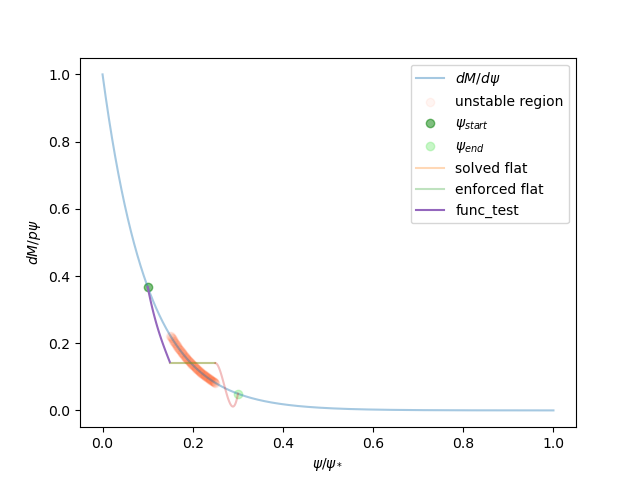

In [139]:
x0 = x[start_index - ghost_points_0]
x1 = x[start_index]
x2 = x[end_index]
x3 = x[end_index + ghost_points_3]

dydx0 = 1.5*(flats[0] - dmdpsi_0)/(x1 - x0)
dydx1 = 1.5*(flats[0] - dmdpsi_0)/(x1 - x0) - 0.5*dydx0
dydx2 = 0
dydx3 = 1.5*(dmdpsi_3 - flats[0])/(x3 - x2)

d2ydx0 = -2*(dydx1 +2*dydx0)/(x1 - x0) + 6*(flats[0] - dmdpsi_0)/(x1 - x0)**2
d2ydx1 = 2*(2*dydx1 + dydx0)/(x1 - x0) - 6*(flats[0] - dmdpsi_0)/(x1 - x0)**2

d1 = (d2ydx1 - d2ydx0)/(6*(x1 - x0))
c1 = (x1*d2ydx0 - x0*d2ydx1)/(2*(x1-x0)) + 3*d1*x0
b1 = ((flats[0] - dmdpsi_0) - c1*(x1-x0)**2 - d1*(x1 - x0)**3)/(x1 - x0)
a1 = dmdpsi_0

func_test = a1 + b1*(x[start_index - ghost_points_0:start_index]-x0) + c1*(x[start_index - ghost_points_0:start_index]-x0)**2 + d1*(x[start_index - ghost_points_0:start_index]-x0)**3

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
# ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.plot(x[start_index - ghost_points_0:start_index], func_test,'-',label="func_test")
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

### unneccessary BCs 2 - remove different conditions
Have found that the dmdpsi curve goes negative when the derivative condition is relaxed. A potential solution is to instead change one of the other derivatives - try the one at the right side of the flat section to begin, instead. This means replacing the row
\begin{equation}
\left(\frac{dy}{dx}\right)_{x = x_{03}} = b_3 = 0
\end{equation}

with the condition that the derivative at the end equal $k_3$, viz.:
\begin{equation}
\left(\frac{dy}{dx}\right)_{x=x_{13}} = b_3 + 2 c_3\Delta L_3 + 3 d_3 \Delta L_3 ^2 = k_3
\end{equation}

0.08649353872877909 0.08649353872877907 0.03834317855144627
total mass = 0.08649353872877909, checkmass = 0.08649353872877909, pct = 0.0%


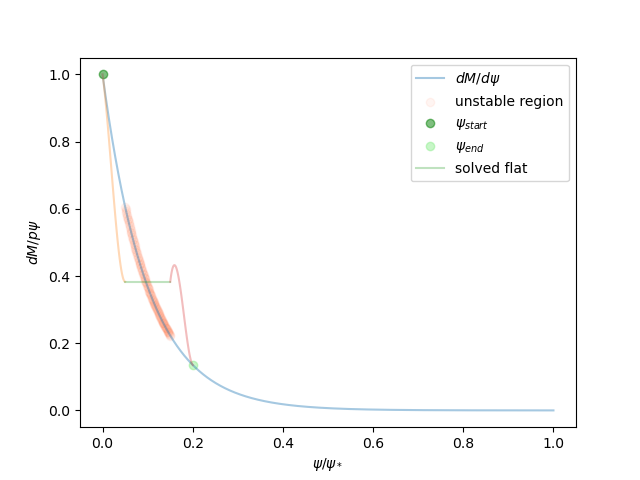

In [140]:
start_index = 50
end_index = 150

mass = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

ghost_points_0 = 50
ghost_points_3 = 50

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]


L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])
mass_1 = simpson(y[start_index - ghost_points_0:start_index+1], x[start_index - ghost_points_0:start_index+1])
mass_3 = simpson(y[end_index:end_index+ghost_points_3 + 1], x[end_index:end_index+ghost_points_3 + 1])

print(total_mass,mass+mass_1+mass_3, mass)

A = [[1, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, L1, L1**2,L1**3, 0, 0, 0, 0, 0],
     [0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 1, 2*L1,3*L1**2, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 1,L3, L3**2, L3**3],
     [0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2],
     [0, 0, 0, 0, 0, 1, 0, 0, 0], 
     [L1, L1**2/2, L1**3/3, L1**4/4, L2, L3,L3**2/2, L3**3/3,L3**4/4]]

b = [dmdpsi_0, flats[0], k0, 0, flats[0], dmdpsi_3, k3, flats[0], total_mass]

xx = np.linalg.solve(A,b)
a1 = xx[0]
b1 = xx[1]
c1 = xx[2]
d1 = xx[3]
a2 = xx[4]
a3 = xx[5]
b3 = xx[6]
c3 = xx[7]
d3 = xx[8]

x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1] - x_10) + c1*(x[start_index-ghost_points_0:start_index+1] - x_10)**2 + d1*(x[start_index-ghost_points_0:start_index+1] - x_10)**3
y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3

# find checkmass
checkmass = simpson(y1,x[start_index-ghost_points_0:start_index+1]) + simpson(y2,x[start_index:end_index+1]) + simpson(y3,x[end_index:end_index + ghost_points_3+1])

print(f"total mass = {total_mass}, checkmass = {checkmass}, pct = {(total_mass - checkmass)/total_mass * 100}%")

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
# ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

### allow a2 to float
Nope, still having issues. The negative mass occurs when the integrated mass of the rest of the splines are too large. Allow y2= a2 to float, and SOLVE for a2, keeping the gradient conditions. This should reduce the likelihood of the mass going negative.

0.011682216314683816 0.011682216314683818 0.005178806563056006
9.359900035431053e-17
total mass = 0.011682216314683816, checkmass = 0.011682216314683814, pct = 1.4849266862113895e-14%


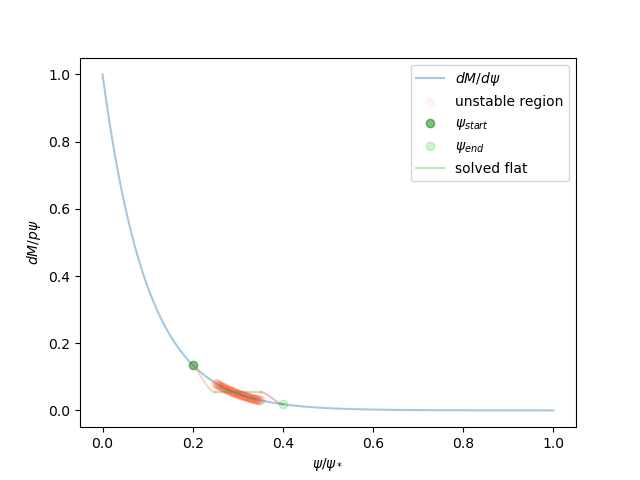

In [141]:
start_index = 250
end_index = 350

mass = simpson(y[start_index:end_index+1],x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

ghost_points_0 = 50
ghost_points_3 = 50

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]


L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])
mass_1 = simpson(y[start_index - ghost_points_0:start_index+1], x[start_index - ghost_points_0:start_index+1])
mass_3 = simpson(y[end_index:end_index+ghost_points_3 + 1], x[end_index:end_index+ghost_points_3 + 1])

print(total_mass,mass+mass_1+mass_3, mass)

A = [[1, 0, 0, 0, 0, 0, 0, 0, 0],
     [1, L1, L1**2,L1**3,-1, 0, 0, 0, 0],
     [0, 1, 0, 0, 0, 0, 0, 0, 0],
     [0, 1, 2*L1,3*L1**2, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 1, -1, 0, 0, 0],
     [0, 0, 0, 0, 0, 1,L3, L3**2, L3**3],
     [0, 0, 0, 0, 0, 0, 1, 2*L3, 3*L3**2],
     [0, 0, 0, 0, 0, 0, 1, 0, 0], 
     [L1, L1**2/2, L1**3/3, L1**4/4, L2, L3,L3**2/2, L3**3/3,L3**4/4]]

b = [dmdpsi_0, 0, k0, 0, 0, dmdpsi_3, k3, 0, total_mass]

xx = np.linalg.solve(A,b)

a1 = xx[0]
b1 = xx[1]
c1 = xx[2]
d1 = xx[3]
a2 = xx[4]
a3 = xx[5]
b3 = xx[6]
c3 = xx[7]
d3 = xx[8]

print(b3)

x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1] - x_10) + c1*(x[start_index-ghost_points_0:start_index+1] - x_10)**2 + d1*(x[start_index-ghost_points_0:start_index+1] - x_10)**3
y2 = a2*np.ones_like(x[start_index:end_index+1]) #+ b2*(x[start_index:end_index+1] - x_20)
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30) + c3*(x[end_index:end_index + ghost_points_3+1] - x_30)**2 + d3*(x[end_index:end_index + ghost_points_3+1] - x_30)**3

# find checkmass
checkmass = simpson(y1,x[start_index-ghost_points_0:start_index+1]) + simpson(y2,x[start_index:end_index+1]) + simpson(y3,x[end_index:end_index + ghost_points_3+1])

print(f"total mass = {total_mass}, checkmass = {checkmass}, pct = {(total_mass - checkmass)/total_mass * 100}%")

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
# ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

### Linear splines
Try linear splines $y_i = a_i + b_i (x - x_{0,i})$:


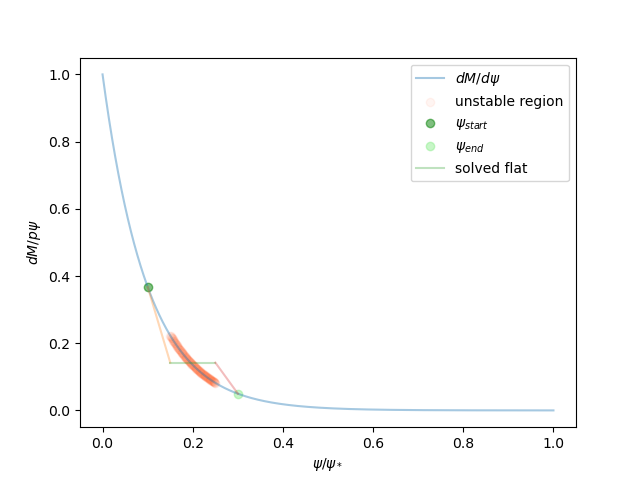

In [142]:
start_index = 150
end_index = 250

mass = simpson(y[start_index:end_index+1], x[start_index:end_index+1])
flats = mass/(x[end_index] - x[start_index])*np.ones_like(x[start_index:end_index+1])

ghost_points_0 = 50
ghost_points_3 = 50

gradient = np.gradient(y,x)
k0 = gradient[start_index - ghost_points_0]
k3 = gradient[end_index + ghost_points_3]

L1 = x[start_index] - x[start_index - ghost_points_0]
L2 = x[end_index] - x[start_index]
L3 = x[end_index + ghost_points_3] - x[end_index]

dmdpsi_0 = y[start_index - ghost_points_0]
dmdpsi_3 = y[end_index + ghost_points_3]
total_mass = simpson(y[start_index - ghost_points_0:end_index+ghost_points_3+1],x[start_index - ghost_points_0:end_index+ghost_points_3+1])
mass_1 = simpson(y[start_index - ghost_points_0:start_index+1], x[start_index - ghost_points_0:start_index+1])
mass_3 = simpson(y[end_index:end_index+ghost_points_3 + 1], x[end_index:end_index+ghost_points_3 + 1])

C = [[1, 0, 0, 0, 0],
     [1, L1, -1, 0, 0],
     [0, 0, 1, -1, 0],
     [0, 0, 0, 1, L3],
     [L1, L1**2/2, L2, L3, L3**2/2]]

d = [dmdpsi_0,0,0,dmdpsi_3,total_mass]

xx = np.linalg.solve(C,d)

a1 = xx[0]
b1 = xx[1]
a2 = xx[2]
a3 = xx[3]
b3 = xx[4]
x_10 = x[start_index - ghost_points_0]
x_20 = x[start_index]
x_30 = x[end_index]
x_31 = x[end_index + ghost_points_3]

y1 = a1 + b1*(x[start_index-ghost_points_0:start_index+1]-x_10)
y2 = a2*np.ones_like(x[start_index:end_index+1])
y3 = a3 + b3*(x[end_index:end_index + ghost_points_3+1] - x_30)

fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
# ax.plot(x[start_index:end_index+1], flats,alpha=0.3, label='enforced flat')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

### Equal mass, rather than equal dmdpsi
Try equal **mass** rather than equal $\frac{dM}{d\psi}$. We know that the size of each flux tube reduces as we get closer to the equator, so we put an equal amount of mass $\Delta M$ in each flux tube, then set each value of dmdpsi according to $\left(\frac{dM}{d\psi}\right)_i = \frac{\Delta M}{\Delta \psi_i}$. The small mass $\Delta M$ is calculated by dividing the total mass in the region by the number of flux tubes, viz. $\Delta M = M_0/N$.

In [143]:
N = end_index - start_index

mass_per_tube = (total_mass - mass_1 - mass_3) / N
dx_i = np.append(x[1:] - x[:-1],0)
adjusted_y = mass_per_tube / dx_i[start_index:end_index+1]

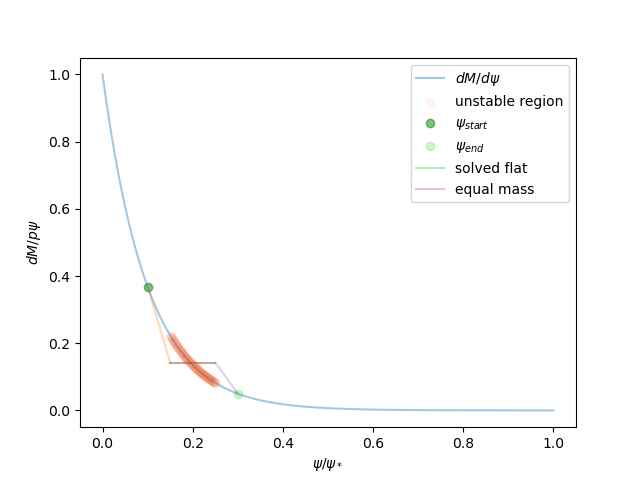

In [144]:
fig,ax = plt.subplots()
ax.plot(x,y,'-',alpha=0.4,label=r"$dM/d\psi$")
ax.scatter(x[start_index:end_index+1],y[start_index:end_index+1],c='orangered',alpha=0.05,label='unstable region')
# ax.scatter(x[start_index:end_index+1],flats,c='orangered',alpha=0.3,label="unstable region")
ax.scatter(x[start_index - ghost_points_0],dmdpsi_0,c='g',alpha=0.5,label=r"$\psi_{start}$")
ax.scatter(x[end_index + ghost_points_3],dmdpsi_3,c='lightgreen',alpha=0.5,label=r"$\psi_{end}$")
ax.plot(x[start_index-ghost_points_0:start_index+1], y1,'-',alpha = 0.3)
ax.plot(x[start_index:end_index+1], y2,'-',alpha=0.3, label='solved flat')
ax.plot(x[start_index:end_index+1], adjusted_y,alpha=0.3, label='equal mass')
ax.plot(x[end_index:end_index + ghost_points_3+1], y3,'-',alpha=0.3)
ax.set(ylabel=r"$dM/p\psi$",xlabel=r"$\psi/\psi_*$")
ax.legend()
plt.show()

### equalise density in individual regions - identify regions testing
The following method is being tested - within a single joined region, equalise the density in the entire region by summing up the total mass inside, and divide by the volume. Then calculate the correspoding mass to be assigned into each fluxtube by subtracting from the fluxtube the pre-existing unstable region mass, and replacing it with the new mass calculated by average density * unstable volume. 

One consideration - what happens when there are multiple, disconnected regions? Need a section which 1) enumerates the number of disconnected unstable regions, 2) assigns each flux surface in each indexed region to that index, and 3) sums the volumes and masses for each index. Test this below:

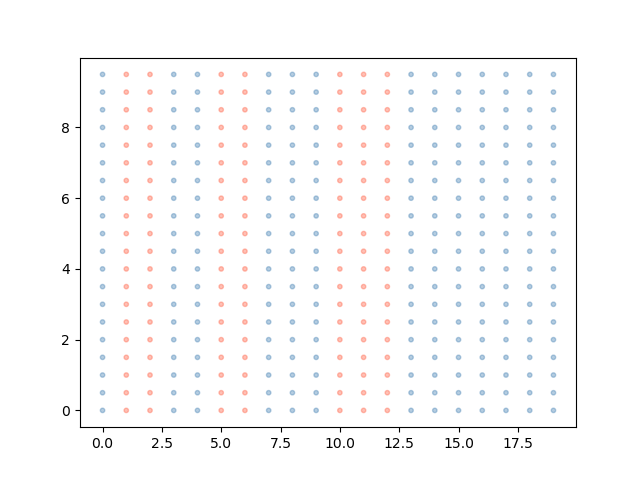

In [180]:
# generate regions
m = 20
l = 20
N = int(l*m)
flux_coords = np.zeros((N,3))
for k in range(m):
    flux_coords[int(l*k):int(l*k+l),-1] = int(k)
    flux_coords[int(l*k):int(l*k+l), 0] = k
    
# Create the pattern array (0-9 repeated m times)
pattern = np.tile(np.arange(0,10,10/l), m).reshape(-1)
# Replace the entries in the original array with the pattern
flux_coords[:,1] = pattern[:]

colours = np.zeros_like(flux_coords[:,0])
colours[flux_coords[:,2] < 3] = 1
colours[flux_coords[:,2] == 5] = 1
colours[flux_coords[:,2] == 6] = 1

colours[flux_coords[:,2] == 10] = 1
colours[flux_coords[:,2] == 11] = 1
colours[flux_coords[:,2] == 12] = 1
colours[flux_coords[:,2] == 0] = 0

fig,ax = plt.subplots()
ax.scatter(flux_coords[:,0],flux_coords[:,1],s=10,alpha = 0.4,c=np.where(colours==1,'tomato','steelblue'))
plt.show()

In [215]:
# enumerate regions
indices = flux_coords[np.where(colours==1)[0],-1].astype(int)
# indices = np.array([int(indices[i]) for i in range(len(indices))])
# extract unique entries
b = np.unique(indices)
print("unique b:", b)

# find adjacent ones
diffs = np.diff(b)
print(diffs)

# calculate where the differences aren't equal to one, then adjust to find the break points
breaks = np.where(diffs != 1)[0] + 1
print("breaks:",breaks)

# add the start and end to be able to calc lengths
breaks = np.concatenate(([0],breaks, [len(b)]))
print(breaks)

interval_lengths = np.diff(breaks)
interval_starts = b[breaks[:-1]]

print("interval start indices:", interval_starts)
print("interval lengths:", interval_lengths)

unique b: [ 1  2  5  6 10 11 12]
[1 3 1 4 1 1]
breaks: [2 4]
[0 2 4 7]
interval start indices: [ 1  5 10]
interval lengths: [2 2 3]


<div class="alert alert-block alert-info">
<b>Note to self:</b> do a run with a flat section followed by a spline, and see whether the flat section is stable. Does this support the hypothesis that the presence of instabilities depends upon the gradient of dmdpsi, or not?
</div>

PS: markdown guide __[here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)__. 


In [218]:
# find masses and volumes for each grouped region
n_points= np.zeros_like(interval_starts)
region_masses = np.zeros_like(interval_starts)
region_vols = np.zeros_like(interval_starts)
unstable_mass = np.zeros(m)
unstable_vol = np.zeros(m)
unstable_densities = np.zeros(m)
adjusted_mass = np.zeros(m)

for i in range(len(interval_starts)):
    unstable_mass[interval_starts[i]:int(interval_starts[i] + interval_lengths[i])] = 10
    unstable_vol[interval_starts[i]:int(interval_starts[i] + interval_lengths[i])] = 5

# manually adjust for effect
unstable_mass[1] = 12
unstable_mass[6] = 8
unstable_mass[11] = 15

for i in range(len(interval_starts)):
    # ii = int(interval_starts[i])
    # print(interval_starts[i],interval_starts[i] + interval_lengths[i]-1)
    # aa = flux_coords[(flux_coords[:,2] >= interval_starts[i]) & (flux_coords[:,2] <= int(interval_starts[i] + interval_lengths[i]-1))]
    # print(aa)

    # we have arrays unstable_mass and unstable_vol that store the total unstable mass and volume per flux surface (i.e. len(unstable_mass) = len(psi_levels). We just need to add the ones corresponding to the indices grouped together
    region_masses[i] = np.sum(unstable_mass[interval_starts[i]:int(interval_starts[i]+interval_lengths[i])])
    region_vols[i] = np.sum(unstable_vol[interval_starts[i]:int(interval_starts[i]+interval_lengths[i])])
    region_densities[i] = region_masses[i]/region_vols[i]
    unstable_densities[interval_starts[i]:int(interval_starts[i] + interval_lengths[i])] = region_densities[i]

for i in range(m):
    adjusted_mass[i] = -unstable_mass[i] + unstable_densities[i]*unstable_vol[i]

# print(unstable_mass)
# print(unstable_vol)
# print(region_masses)
# print(region_vols)
# print(region_densities)
# print(unstable_densities)
# print(adjusted_mass)


### Checking correct calculation of region density

Need to be very careful when calculating the average density in the unstable region. We must consider the following factors:
- the $N$ unstable flux surfaces are located at $\psi = \{\psi_i \psi_{i+1}... \psi_{n-1}, \psi_n\}$
- the corresponding flux _tubes_ containing the unstable mass are enumerated by the flux surfaces $\psi = \psi_{i-1}, \psi_i, \psi_{i+1} ... \psi_{n-1}, \psi_n$, because the mass in the flux tubes are determined by the value of $dM/d\psi$ at the left flux surface values $\psi_i$.
- Consider the following toy setup:
    - two unstable flux surfaces, $\psi_1, \psi_2$
    - the mass in the relevant flux tubes are:
        - $M(\psi_0) = M_0$
        - $M(\psi_1) = M_1$
        - $M(\psi_2) = M_2$

<div class="alert alert-block alert-info">
<b>Note to self:</b> need to check with Andrew whether it is reasonable to calculate `mass_a` in the way we do - i.e. is it reasonable to calculate the mass element on the reverse side in that way, given you can show that `mass_a` of the current iteration doesn't currently equal `mass_b` of the previous (when they should?)
</div>